# 기존 실제 데이터 실험 결과 — 보관된 결과의 스냅샷

**독립 테스트셋 성능이 아닌 기존 검증셋 결과입니다.** 아래 값은 완료된 CSV 원문을 노트북 안에 포함한 것입니다. 새 컴퓨터에서도 원래 결과 폴더 없이 볼 수 있습니다. 경로와 SHA-256은 출처 확인용이며 실행 경로가 아닙니다.

- 원본/랜덤/클러스터: 6종 × 3시드 × 3방식 = 54개 GNN 실험. 같은 클러스터 검증 ID·IPW를 사용한 결과입니다.
- 잠재공간 증강: 6종 × 3시드 × 4조건 = 72개 새 분류기 실험. 고정 인코더와 클러스터 학습 표본 위의 추가 증강입니다.
- 원본/다운샘플링 표와 증강 표는 학습 절차가 달라 직접 이어 붙인 성능 순위가 아닙니다. 증강 효과는 증강 표의 none과 비교하세요.
- 36피처와 고정 인코더 선택에도 기존 검증셋이 쓰였으므로 독립적인 일반화 성능 주장이 아닙니다. 표준편차는 세 학습 시드의 변동이고 신뢰구간·유의성 검정 결과가 아닙니다.


In [ ]:
import io, hashlib
import pandas as pd
import matplotlib.pyplot as plt
SNAPSHOTS = [{'path': 'experiments/gnn36_distribution_v1/seed_summary.csv', 'sha256': '32c22ee5e5765e7807ef890f07420c7a132a9026d5a273e619f9f26d0eeb0a44', 'csv': 'method,model,seeds_completed,AP_mean,AP_std,precision_mean,precision_std,recall_mean,recall_std,F1_mean,F1_std,accuracy_mean,accuracy_std,FPR_mean,FPR_std,ROC_AUC_mean,ROC_AUC_std,recall_at_1_percent_mean,recall_at_1_percent_std,unmatched_recall_at_1_percent_mean,unmatched_recall_at_1_percent_std\ncluster_under,edge_sage,3,0.5869686655477369,0.009340691540217471,0.7831628702992895,0.012146783858258316,0.5135095555392839,0.011724829176277317,0.6202736139961231,0.01164390590114488,0.9992346067712651,2.104478559074456e-05,0.00017330160797697966,9.84900527388004e-06,0.9898055669351505,0.0002215651214308881,0.8493324546630543,0.0026292222322120903,0.6331555928344618,0.0055518583155199685\ncluster_under,edge_weighted_gcn,3,0.580884825945688,0.015323238198376589,0.7801966768734184,0.036349414532818286,0.4996949061531328,0.01642868240639786,0.6091657351605366,0.02281676824952776,0.9992190742726178,5.0168504770837546e-05,0.00017201318815974207,3.1536382676444024e-05,0.9896160338252503,0.0001254826659110749,0.8434909244750353,0.0019382593922546755,0.6211331456074132,0.004845265554154471\ncluster_under,gat,3,0.5896709230441353,0.0051659218979424135,0.809497000148232,0.03066357287028814,0.49875928502273964,0.006077632797599928,0.6169978010515654,0.0061563376464944235,0.9992459132040697,2.5027111169170982e-05,0.00014400103219224645,3.068706909659153e-05,0.9896608058025134,0.000214838436245293,0.8460293052809712,0.002232497687973787,0.6274838735446249,0.005331990569938199\ncluster_under,gatv2,3,0.580829095543551,0.007743090923417188,0.7935580155948304,0.01288125230351248,0.49681482023870543,0.007779182373456346,0.6110105362032493,0.006620658025117894,0.9992298647811692,1.3460978817013847e-05,0.00015769874420021245,1.3047686487281064e-05,0.9895895236881369,0.0001384995036791821,0.8454679326027352,0.0008463224856936529,0.6262257104627243,0.0019692303974724167\ncluster_under,gine,3,0.5656395132079637,0.005265533284475113,0.7526842512558626,0.00261626978450324,0.5050076070065819,0.0037012867578820477,0.6044543002412035,0.0031156231802415267,0.9991953202740521,4.96603553178198e-06,0.0002022722459032478,2.5645959378566984e-06,0.9889706987154288,0.0005076946447940941,0.8443207797385143,0.0021369234184215246,0.6231302298643979,0.0053286234928116676\ncluster_under,tgnn,3,0.6211238772714331,0.005863783987901558,0.8071463733824124,0.014448542246689107,0.5427334781512126,0.012368763936747596,0.6488714928025544,0.004306175018494296,0.9992850012733072,3.203957351352197e-06,0.00015846920325308488,1.8071050882832494e-05,0.990327579482598,0.00012010631637334306,0.8570940421273584,0.0018480529346304353,0.6515087971561521,0.0043511236932506055\noriginal,edge_sage,3,0.6059283631041258,0.012045357870115563,0.7923884862770659,0.016509348982934366,0.5440352118978464,0.004720776288391945,0.6450455666926204,0.0023793739668969663,0.9992709742651678,1.3541589047771382e-05,0.000174100104203465,1.917833160143991e-05,0.9890088402082117,0.0005654880430416264,0.8436129620137821,0.009640481518111046,0.6200147784235016,0.0232117813638537\noriginal,edge_weighted_gcn,3,0.614132833558843,0.005535451849800442,0.8255610443452124,0.020667015290180935,0.5487946759089762,0.010568601170089339,0.6591867019308298,0.00928902532265519,0.9993090875036995,2.1446501307885185e-05,0.000141742122115796,2.1300535722706698e-05,0.9879631019118426,0.0007592660333458856,0.8343299732330998,0.004533580956971271,0.5988257144568929,0.01094351151237617\noriginal,gat,3,0.6134089646422919,0.002001929910685563,0.8191029403329372,0.0038110607062772457,0.5536680416229366,0.0023729738377644733,0.6607184560145279,0.0018658739110245378,0.9993077044561317,4.004576973223293e-06,0.00014906741599689935,4.0356497609378646e-06,0.9867220018836557,0.0008280978759049027,0.8281386021006728,0.002841597203894665,0.5850258622411278,0.007467786756147438\noriginal,gatv2,3,0.6113386824384502,0.016352255941040637,0.8400138775362702,0.013183792282143152,0.5436365559379399,0.011420766423088702,0.6599420472270588,0.004439880253442417,0.99931801699296,1.451905033701485e-06,0.00012651407633309643,1.4919872475013025e-05,0.9870202366870399,0.0011139214269500195,0.8324668668082301,0.009976581854673927,0.5948515167854932,0.0237374866310248\noriginal,gine,3,0.6001259817500546,0.009428341667643118,0.8067676684373337,0.04773047416936529,0.5455891565578904,0.019627587379900415,0.6500719465496478,0.007764251366835474,0.9992846789255742,3.52604689207075e-05,0.00016227297347265487,5.53345016456869e-05,0.988428370100716,0.00027043675882368085,0.8393660556653894,0.0037483871910483297,0.6107483074710923,0.009155645790183213\noriginal,tgnn,3,0.6027666316824568,0.0031297379373271222,0.7801399621647365,0.0306069605232568,0.5449871047000724,0.009102538876407754,0.6413913385914419,0.00538080875636349,0.9992578340954993,2.606428021311161e-05,0.00018841663472669162,3.5882220472273616e-05,0.9872719244652126,0.0014746399044064749,0.8317102340679993,0.01003801598244851,0.5936532662313022,0.023325166134861075\nrandom_under,edge_sage,3,0.5648221815220512,0.01721484409089945,0.7447481899182741,0.03283537619236065,0.5117522149813283,0.008846534769697044,0.6065200544534918,0.015363320888269675,0.9991912002122052,4.106627754406718e-05,0.0002146189069570539,3.426198974639966e-05,0.9896436728471297,0.00022837388282650323,0.8474286690586025,0.001416266537443931,0.628502386515687,0.002980209163739356\nrandom_under,edge_weighted_gcn,3,0.585979026258876,0.002166815947943525,0.7960705424374078,0.011980242003559499,0.5004840822370294,0.00842770896860434,0.6145535792305725,0.00844307399673346,0.9992356790450653,1.6252891052394545e-05,0.0001563501686623241,1.082629206637447e-05,0.9895682228709645,0.0001793168719543962,0.8402691334521165,0.0038150998445738407,0.6143630299762347,0.009590184917129738\nrandom_under,gat,3,0.5938016624366972,0.007176788483799211,0.8010446999056203,0.008336011876070462,0.5168859274446153,0.006329141765402529,0.628326227504273,0.00691129459769656,0.9992555036213134,1.3275348801515382e-05,0.0001564950321666482,6.75055724924136e-06,0.9896356708758193,0.00015353574558325646,0.8455574267978164,0.0032123779158926397,0.6254268767599306,0.006808973767982908\nrandom_under,gatv2,3,0.5967798517225694,0.0039134991013018445,0.8115861686052775,0.01596064324504634,0.5075541236484343,0.01729960347438153,0.6243049122373925,0.011074643869470557,0.9992565911169743,1.442826322169992e-05,0.00014403088068527865,1.865385335552978e-05,0.9896092206119019,8.231556955376236e-05,0.8455818343055657,0.0007484526865087831,0.6250474307511035,0.0011987497212836297\nrandom_under,gine,3,0.5584455031622473,0.0037142416826958942,0.7014523481575657,0.029428884506093184,0.5227681368122168,0.01582435562587535,0.5987483408297677,0.013350153330581298,0.9991468069193598,3.818907096061177e-05,0.00027249455960904565,4.206349692246745e-05,0.9889871421203175,0.0004399033604108786,0.8405782952169419,0.004245105796113813,0.6125456833023785,0.010245042238332034\nrandom_under,tgnn,3,0.6159355775775989,0.002717077630274045,0.7838918010781404,0.013907453850745231,0.5436772351175221,0.005637394620141849,0.6419912549051069,0.004644052790031242,0.9992617177705657,1.374622219273879e-05,0.00018293151395836098,1.6056837410320635e-05,0.9897367961176772,0.0006344698509273446,0.8533271500980368,0.0021548295538750943,0.6424620054720109,0.004942813794797131\n'}, {'path': 'experiments/gnn36_latent_oversampling_v1/seed_summary.csv', 'sha256': '4e8ab9b12dcf8014573b9d8a909c4f6e02ac56c2fa853ffa96eeed58d26c81d5', 'csv': 'model,method,seeds,AP_mean,AP_std,AP_gain_pp,precision,recall,F1,ROC_AUC,recall_at_1_percent\nedge_sage,none,3,0.5669318771439543,0.024936878099790463,0.0,0.7514922348059835,0.516226924735382,0.6118232891752023,0.9899907392519128,0.8499833215363712\nedge_sage,repeat,3,0.5564084991405421,0.020302063987823492,-1.0523378003412187,0.7182323426540337,0.5137699022886107,0.5985940858002191,0.9900073564187002,0.8499182348490395\nedge_sage,smote,3,0.5568584133649509,0.01782040803676569,-1.007346377900331,0.71901525071351,0.5113128798418393,0.5974376318758094,0.9899584032392242,0.8490883795855605\nedge_sage,wgan_gp,3,0.5525684710466102,0.03920308107511395,-1.43634060973441,0.7098174935614416,0.5226949142889686,0.6014370785461813,0.989570274236318,0.8456957360083962\nedge_weighted_gcn,none,3,0.5615133502917029,0.037243002619167236,0.0,0.770188436415113,0.5035675640493683,0.6088660855290849,0.9901037197984155,0.8459479469218065\nedge_weighted_gcn,repeat,3,0.5610013810279016,0.04153231315285791,-0.05119692638012596,0.7407555557819707,0.5168371124291166,0.6086127375222977,0.9897863667452164,0.8426203900319739\nedge_weighted_gcn,smote,3,0.5644405455804232,0.035245017110105165,0.2927195288720245,0.7549787697171992,0.5106782846403554,0.609236158080468,0.9898698801844524,0.8446624848470057\nedge_weighted_gcn,wgan_gp,3,0.5773117817914059,0.02208639128821538,1.579843149970302,0.7634964856165413,0.51023081366495,0.6112606220251146,0.9897869077553864,0.8434583811313693\ngat,none,3,0.5618515919963677,0.027739865033723346,0.0,0.771691278221275,0.5094416375810532,0.6131858452323398,0.9898739784838445,0.8478598683621749\ngat,repeat,3,0.5630093255764611,0.020266267996921807,0.11577335800933379,0.7875754443593422,0.5029085613401348,0.6138361551189738,0.9897835479007013,0.8469242472317818\ngat,smote,3,0.5699267031137305,0.012093430513057732,0.807511111736281,0.7833619737079743,0.518008672801087,0.6235389376240638,0.9900756818955263,0.8499100990131231\ngat,wgan_gp,3,0.5768905824604137,0.0205612731427451,1.5038990464045998,0.7491200804229342,0.5248509108068308,0.6166964384256924,0.9896777186100641,0.8466720363183716\ngatv2,none,3,0.5656714542637279,0.003469882992067228,0.0,0.7480820151712696,0.5260143353428849,0.6171472200318435,0.9898364757874037,0.8461920219993003\ngatv2,repeat,3,0.5686645218700129,0.0046598303626259555,0.2993067606285038,0.7780217700047732,0.525753988593558,0.627315771347016,0.9899447787416694,0.8473473106994378\ngatv2,smote,3,0.5694643563520488,0.0024221863153835073,0.3792902088320986,0.7747021025402591,0.5236468070911946,0.6248973729574296,0.98977950956282,0.8463628745535461\ngatv2,wgan_gp,3,0.5680467757175741,0.005082549239128987,0.23753214538463352,0.7238558995917123,0.5244685265187572,0.6081405265257219,0.9891276904877025,0.8407816911148536\ngine,none,3,0.5683489979920449,0.006622039784457776,0.0,0.744127059477716,0.5103447153677805,0.6050822203788773,0.9898473263754594,0.8450367332991627\ngine,repeat,3,0.5636608338935213,0.016202235966628318,-0.468816409852361,0.7319697642408186,0.5094904525965521,0.6006894780225043,0.989715498623601,0.8437024562088632\ngine,smote,3,0.5733578812828196,0.00486298978752871,0.500888329077472,0.7544863713696409,0.5119230675355739,0.6097495826370709,0.989794634655481,0.8452075858534084\ngine,wgan_gp,3,0.5544628124422796,0.011671585850630845,-1.3886185549765357,0.7268259764271755,0.5055933871925671,0.5960993718485849,0.9897348179096729,0.8433770227722047\ntgnn,none,3,0.5966471075305729,0.02400117264004221,0.0,0.7832443201007274,0.5310422819392578,0.6329440217440797,0.9902150764201888,0.8539698811354373\ntgnn,repeat,3,0.6024969247186829,0.01973769290376544,0.5849817188109915,0.7788349271620923,0.5381285950224955,0.636426747944762,0.990233165940788,0.8539373377917713\ntgnn,smote,3,0.5990912005745476,0.0227122053673174,0.24440930439745637,0.7915663232257134,0.5301473399884471,0.6348312208723882,0.9903452147631628,0.8547021063679189\ntgnn,wgan_gp,3,0.6043842373312384,0.013728825371972477,0.7737129800665506,0.7672847145652514,0.5376160373597585,0.6321021497650741,0.9901698884804709,0.8535468176677812\n'}]

## 결과 원문과 출처 확인

In [ ]:
for snapshot in SNAPSHOTS:
    assert hashlib.sha256(snapshot['csv'].encode()).hexdigest() == snapshot['sha256']
    print(snapshot['path'], snapshot['sha256'])
original_results = pd.read_csv(io.StringIO(SNAPSHOTS[0]['csv']))
latent_results = pd.read_csv(io.StringIO(SNAPSHOTS[1]['csv']))
assert len(original_results) == 18 and (original_results.seeds_completed == 3).all()
assert len(latent_results) == 24 and (latent_results.seeds == 3).all()
display(original_results[['method','model','seeds_completed','AP_mean','AP_std','F1_mean']])
display(latent_results[['model','method','seeds','AP_mean','AP_std','AP_gain_pp','F1']])

## 기존 결과 비교 그림

AP를 0~1 척도로 표시합니다. 오차 막대는 세 시드의 표준편차입니다. 증강 효과의 pp는 퍼센트포인트입니다.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
p = original_results.pivot(index='model', columns='method', values='AP_mean')
e = original_results.pivot(index='model', columns='method', values='AP_std').reindex_like(p)
p.plot.bar(yerr=e, capsize=2, ax=axes[0]);axes[0].set_title('Historical validation AP: sampling methods')
p = latent_results.pivot(index='model', columns='method', values='AP_mean')
e = latent_results.pivot(index='model', columns='method', values='AP_std').reindex_like(p)
p.plot.bar(yerr=e, capsize=2, ax=axes[1]);axes[1].set_title('Historical validation AP: latent augmentation')
fig.tight_layout();plt.show()
fig, ax = plt.subplots(figsize=(10, 4))
latent_results.pivot(index='model',columns='method',values='AP_gain_pp').plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=.6);ax.set_title('Historical AP gain vs matched none (percentage points)')
fig.tight_layout();plt.show()
print('증강별 모델 평균 AP 변화(pp):')
display(latent_results.groupby('method').AP_gain_pp.agg(['mean','min','max']))

## 해석

양수 변화는 같은 절차의 none보다 AP가 높았다는 뜻이고 음수는 낮았다는 뜻입니다. 생성 그림이 좋아 보여도 실제 검증 성능이 개선되지 않을 수 있습니다. 최댓값만으로 우열을 확정하지 말고 시드별 변동과 검증셋 재사용을 함께 고려해야 합니다.

# 기존 실제 표본의 시각화와 재검증 기록

아래는 **2026-09-27에 기존 실험 산출물에서 추출·검사해 저장한 시각화**입니다. 위에서 새로 실행한 인공 데이터 데모와 다릅니다. 이미지가 노트북 안에 포함되어 있어 원래 그림 파일 없이 볼 수 있습니다. 이 부분의 재검증 수치는 저장된 감사 기록을 인용한 것이며 이번 통합본 실행에서 대용량 원본을 다시 검사한 결과는 아닙니다.

출처: `reports/gnn_sampling_tables_2026-09-26/build_evidence_visuals.py`, 같은 폴더의 `evidence_visuals/audit.json` 및 `test_verification.txt`.


## 실제 클러스터 표본

2022-08-08의 저장된 정상 표본 19,272건에 적합한 PCA이며 그림에는 그중 3,000건을 표시했습니다. 입력은 기존 실험의 표준화된 거래 특징 18개, PCA 두 축 설명분산은 56.36%입니다. 색은 저장된 32개 군집 ID입니다. 원본 정상 거래 전체를 표시한 그림도, PCA 좌표에서 새로 군집화한 그림도 아닙니다. 오른쪽은 정상 원본·추출 표본·IPW 보정 군집 비중입니다.

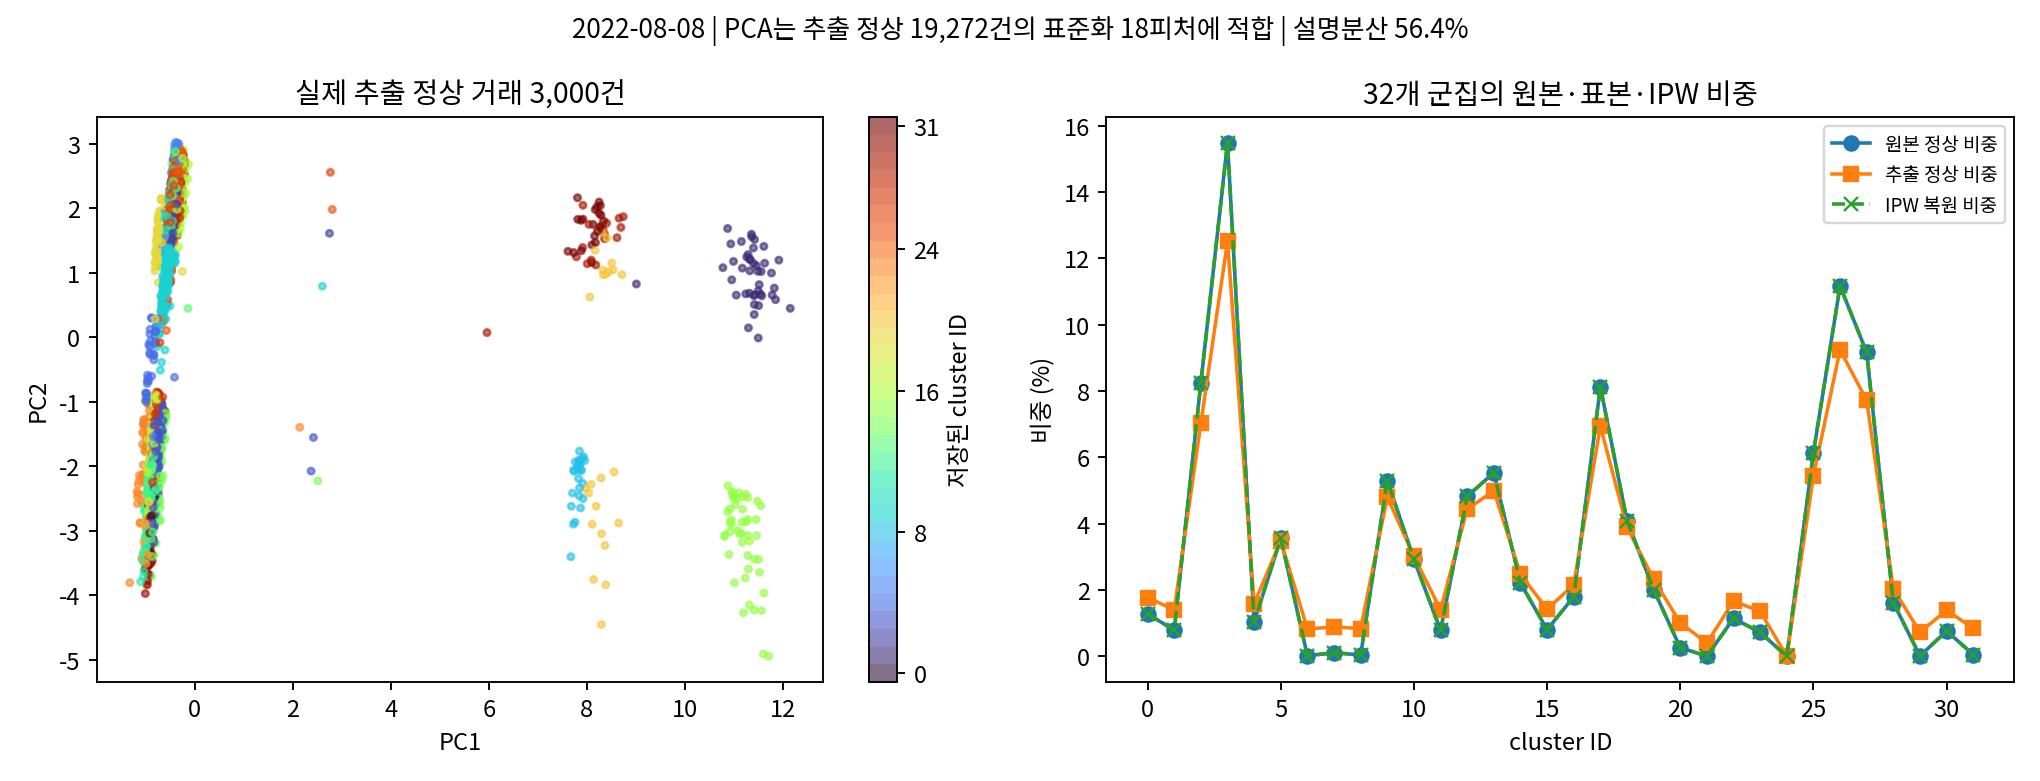

출처: `evidence_visuals/cluster_sample.png` · SHA-256: `3483c8663b6a2b161a917d14ee1cc22f8b404e34cfa74f4028e6c6561278f338`

## 군집별 할당과 추출률

군집별 원본 규모와 실제 추출 수, 추출률을 비교합니다. 작은 군집 보존 때문에 전체 평균 1%와 군집별 추출률은 다릅니다.

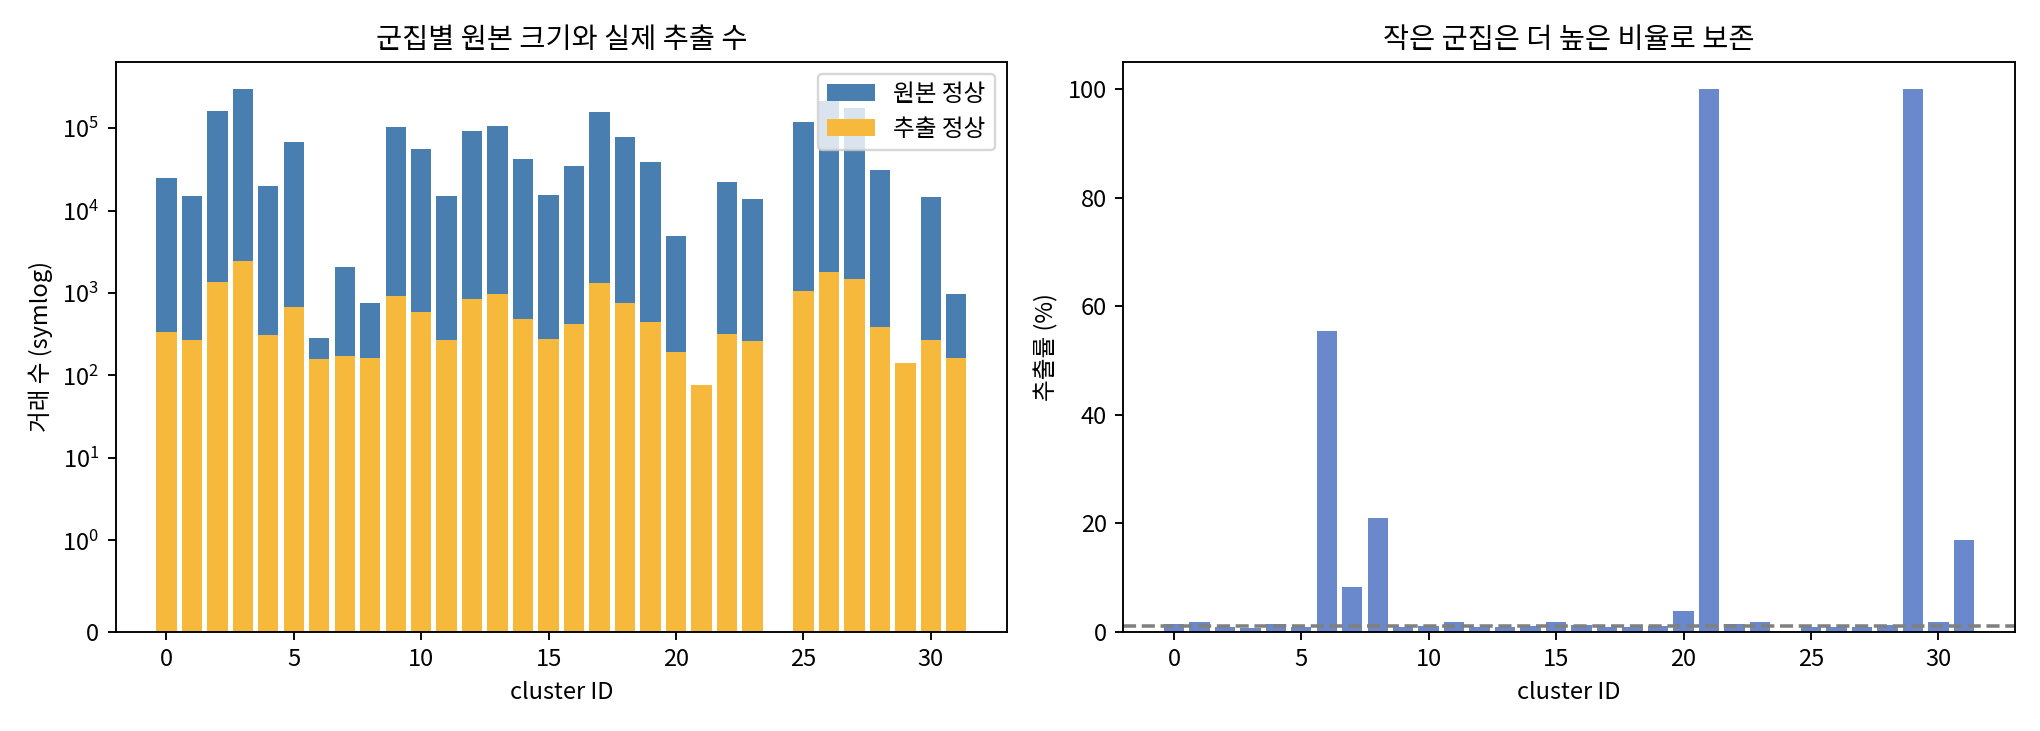

출처: `evidence_visuals/cluster_allocation.png` · SHA-256: `00adf06f375b3d1b4a17c5ad6ee93c384408d21e4a111bd433b74c3e00ccf872`

## 기존 전체 분포 감사

기존 실험의 62개 역할별 주변분포(거래 18개 + 송신 계좌 22개 + 수신 계좌 22개)를 검사한 결과입니다. 36피처 자체의 36개 분포로 오해하면 안 됩니다. 로그 축의 KL은 0에 가까울수록 원본의 해당 주변분포와 비슷합니다. IPW 보정 전후와 같은 규모의 랜덤 표본을 함께 비교합니다.

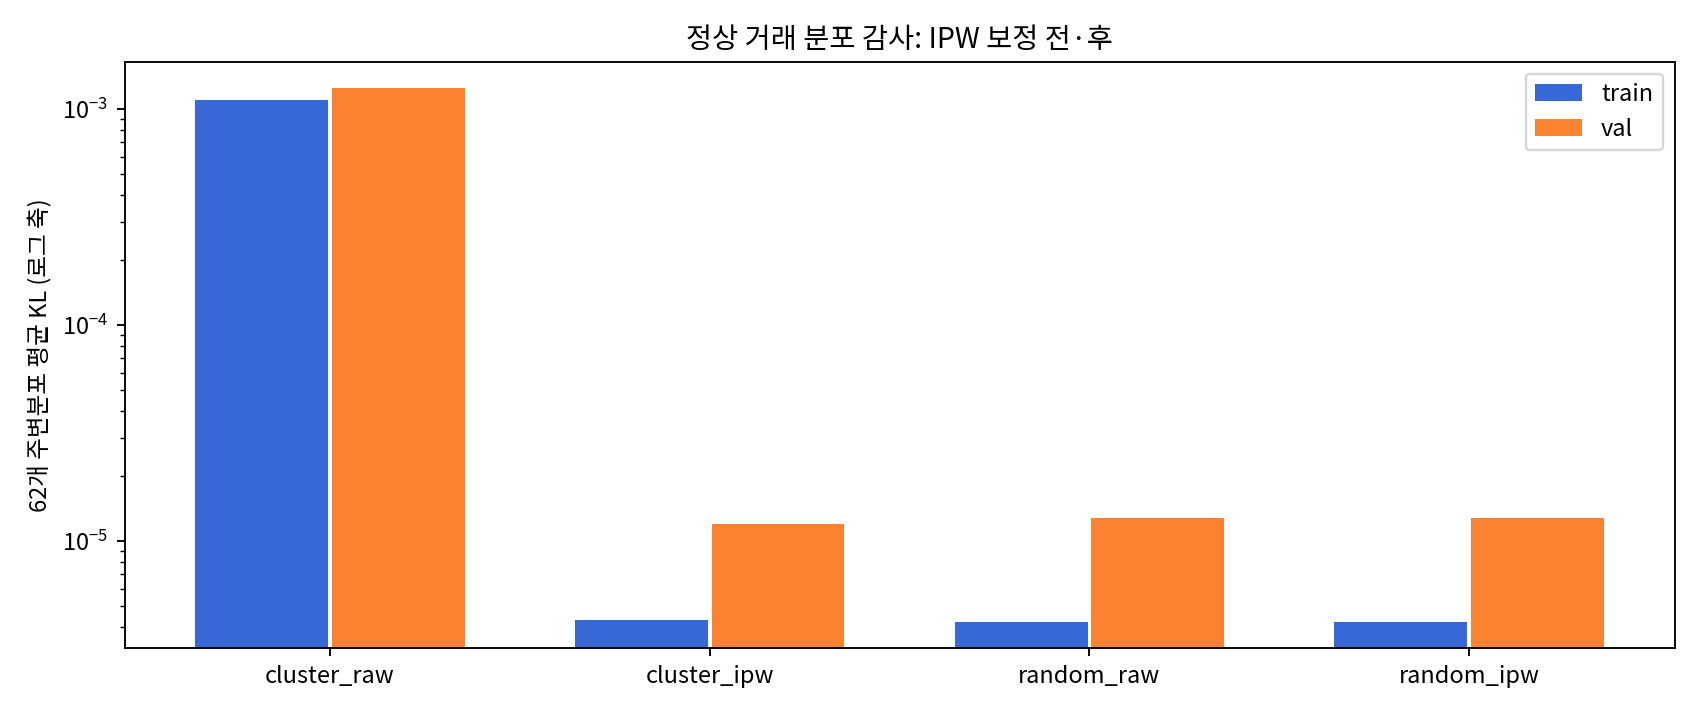

출처: `evidence_visuals/cluster_kl.png` · SHA-256: `2da2fe4cccf485ab0e97b77e75f2f61d78fb1ce451c4fe6380072424413e51b0`

## 실제 저장된 TGNN 증강 표본

TGNN seed 42의 표준화된 128차원 학습 이상 거래 표현 10,000건으로 공통 PCA를 적합했습니다. 실제와 각 생성 풀에서 동일한 행 번호 2,000건을 표시했습니다. 두 축 설명분산은 80.33%입니다. 반복/SMOTE/WGAN-GP 그림은 저장된 생성 풀에서 가져온 것이며 원본 계좌·거래 그래프를 합성한 그림이 아닙니다.

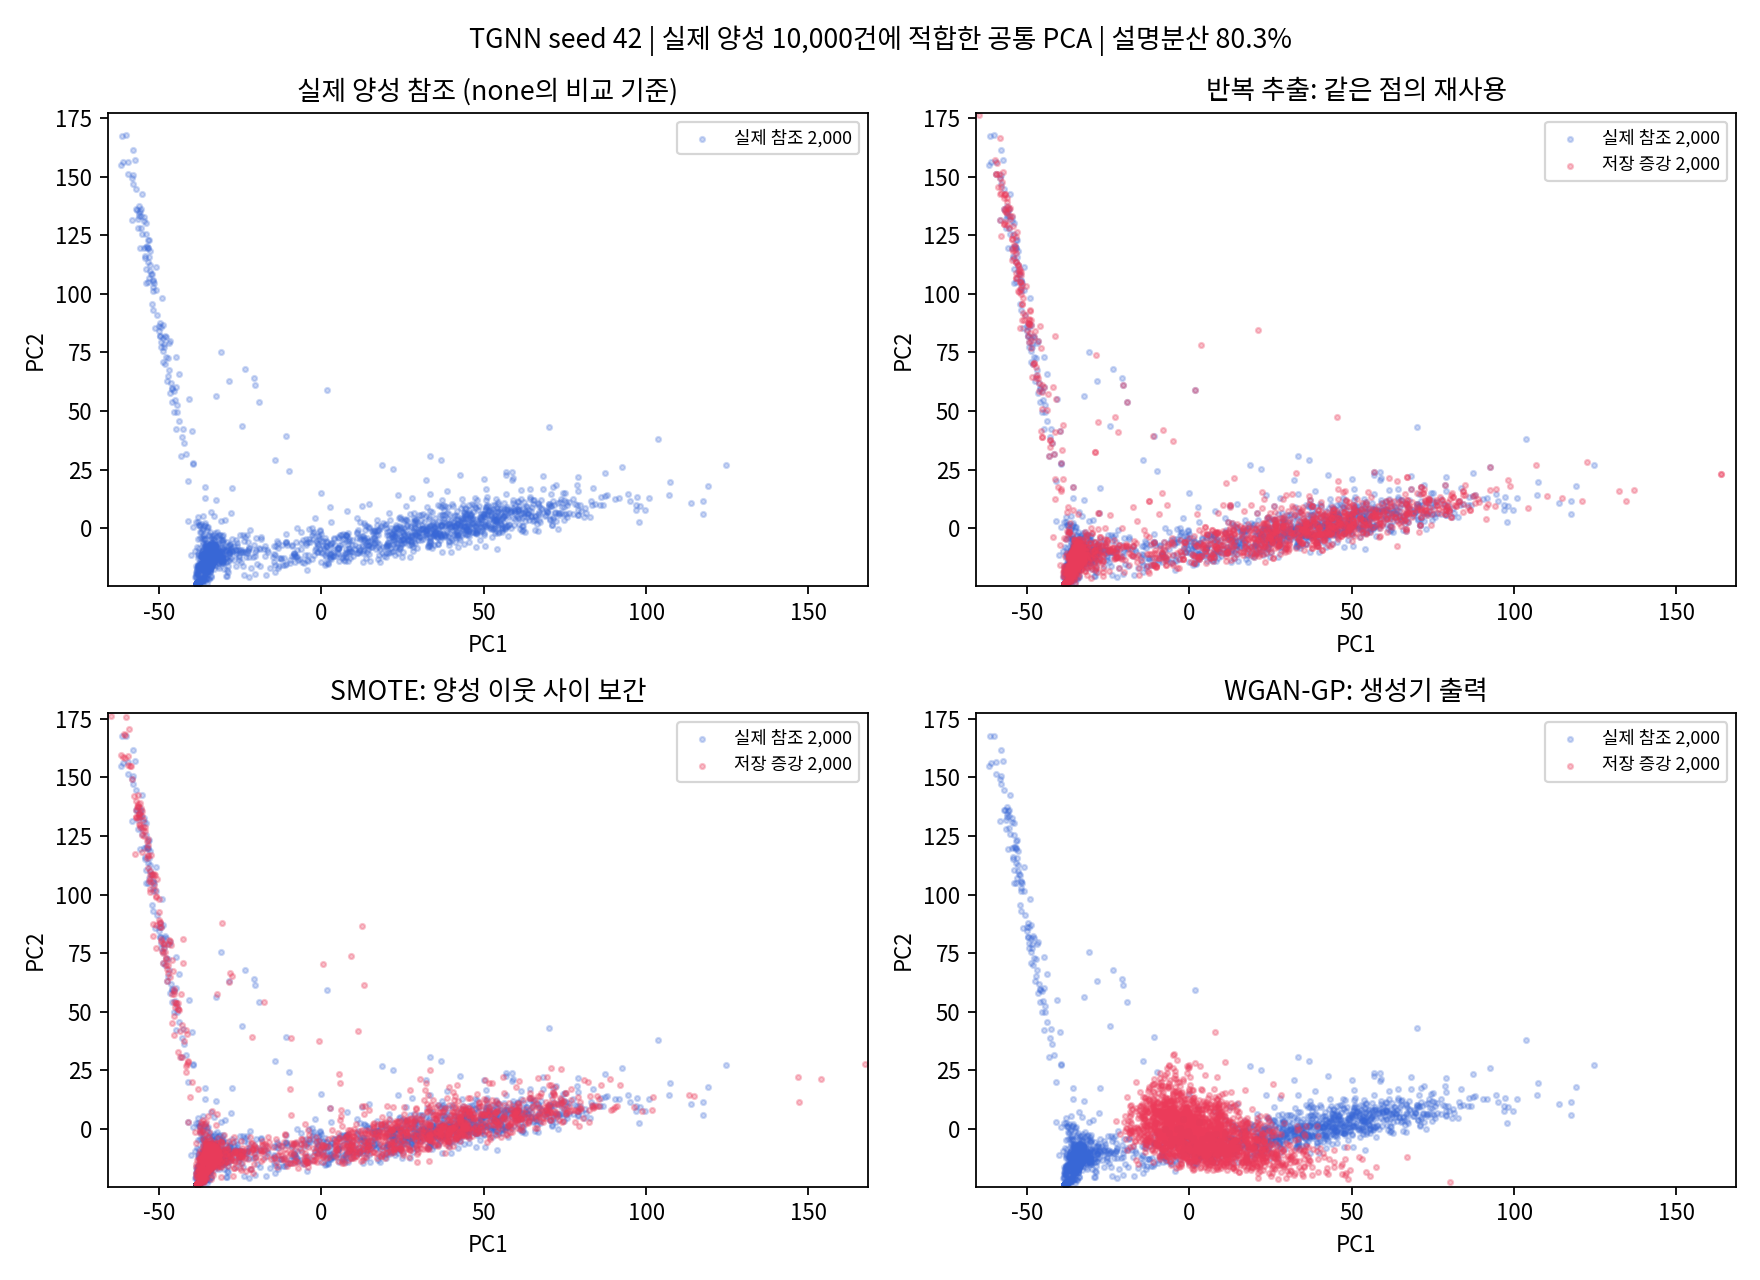

출처: `evidence_visuals/augmentation_pca.png` · SHA-256: `de6636935cae77ccd2a0c99c9dd8c08c8fb4baed40569e5bfe51fc49c5f894de`

## 기존 증강 품질 진단

128차원 표준화 공간에서 첫 2,048개 생성 표현의 실제 참조까지 최근접 거리와, 전체 생성 풀의 차원별 표준편차 비율 중앙값을 비교합니다. 반복 추출은 복제이므로 거리가 0인 것이 예상됩니다. SMOTE는 가까운 보간이고 GAN은 더 넓게 퍼질 수 있지만, 거리나 분산이 크다는 사실만으로 성능이 좋다는 결론을 내릴 수 없습니다.

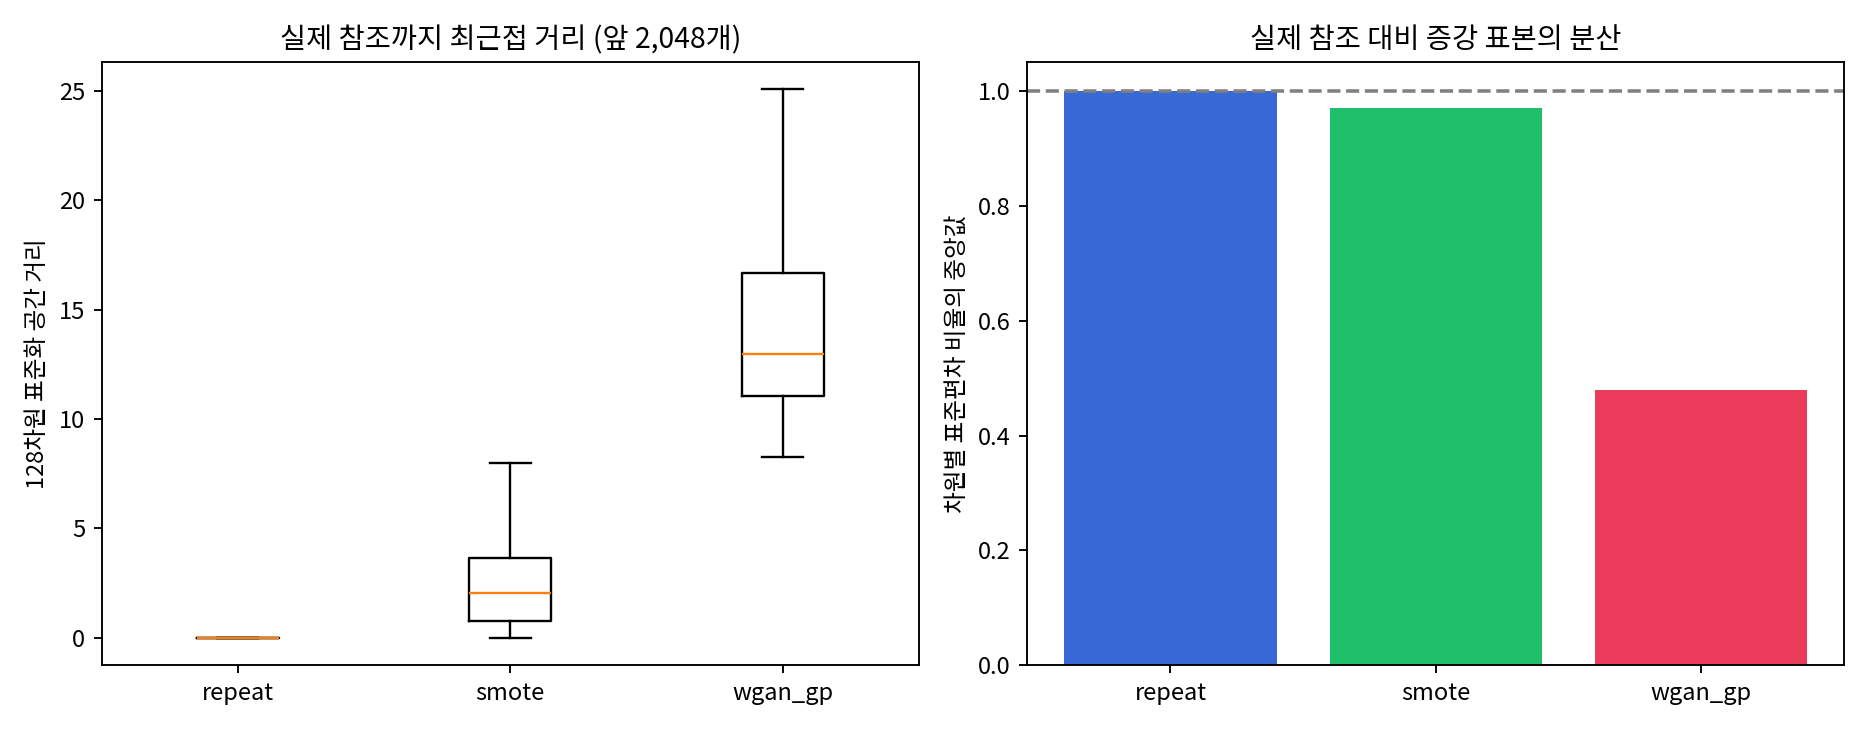

출처: `evidence_visuals/augmentation_diagnostics.png` · SHA-256: `c7606187ea73df143a67ef25104bf90da08aa339d001820ae66809575a5e4c56`

## 기존 감사 기록의 확인 항목

| 항목 | 저장된 확인 결과 |
|---|---:|
| 군집·표본 검사 날짜 수 | 68일 |
| 기존 군집 적합 참조 정상 수 | 208,896건 |
| 재예측 군집 ID 일치율 | 100% |
| 일별 KL 재계산 최대 절대 오차 | 9.93e-17 |
| 표현 파일 해시 확인 | 68개 |
| 저장 검증 점수 재현 최대 절대 오차 | 2.98e-07 |
| 저장 반복 추출 풀 재현 | True |
| 저장 SMOTE 풀 재현 | True |
| 기존 GAN 진단 건수 | 18 |
| 기존 진단 기준상 붕괴 판정 | 0건 |

저장된 테스트 로그에는 잠재공간 증강 구성요소 검사 **6개 통과**, 별도 원본 거래 반복 추출 실험 검사 **5개 통과**가 기록되어 있습니다. 후자의 원본 거래 반복 추출 실험 전체 코드는 이 통합본에 포함되지 않습니다. 기존 GAN 18건의 붕괴 판정 0건은 해당 휴리스틱 진단 결과이며, 모든 생성 표본이 현실적이라는 증명은 아닙니다.

**이번 통합본 실행:** 인공 데이터에서 GNN 6종 학습, 6종×4조건=24개 증강 비교, 코드 검사 5항목 및 모델별 데이터 분리/SMOTE 수식 검사를 통과했습니다. 독립 테스트셋 평가를 새로 수행하지 않았습니다.
